<a href="https://colab.research.google.com/github/Sneha-1503/Disease_Prediction/blob/main/Disease_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import joblib
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, classification_report

In [2]:
from google.colab import files

uploaded = files.upload()


Saving Disease and symptoms dataset.csv to Disease and symptoms dataset.csv


In [3]:
df = pd.read_csv("Disease and symptoms dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (246945, 378)


In [4]:
print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nNumber of diseases:")
print(df["diseases"].nunique())


Missing values:
0

Duplicate rows:
57298

Number of diseases:
773


In [5]:
df = df.drop_duplicates()

print("\nDataset after removing duplicates:")
print(df.shape)



Dataset after removing duplicates:
(189647, 378)


In [6]:
disease_counts = df["diseases"].value_counts()

valid_diseases = disease_counts[disease_counts >= 2].index

df = df[df["diseases"].isin(valid_diseases)]

print("\nDataset after removing extremely rare diseases:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Diseases:", df["diseases"].nunique())


Dataset after removing extremely rare diseases:
Rows: 189601
Columns: 378
Diseases: 727


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop("diseases", axis=1)
y = df["diseases"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (151680, 377)
Testing data: (37921, 377)


In [10]:
from sklearn.model_selection import train_test_split

X = df.drop("diseases", axis=1)
y = df["diseases"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 151680
Testing samples: 37921


In [11]:
from sklearn.linear_model import LogisticRegression

model_20 = LogisticRegression(
    max_iter=200,
    solver="lbfgs",
    multi_class="multinomial",
    n_jobs=2
)

print("Training model...")

model_20.fit(X_train, y_train)

print("Training completed!")

Training model...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training completed!


In [12]:
from sklearn.metrics import accuracy_score, f1_score

y_pred = model_20.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

f1_macro = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

f1_weighted = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("===================================")
print("MODEL 2 PERFORMANCE")
print("===================================")

print("Accuracy:", round(accuracy * 100, 2), "%")
print("Macro F1:", round(f1_macro, 4))
print("Weighted F1:", round(f1_weighted, 4))

MODEL 2 PERFORMANCE
Accuracy: 83.09 %
Macro F1: 0.6948
Weighted F1: 0.8302


In [24]:
joblib.dump(model_20, "disease_prediction_Logistic_regresion.pkl")

# Save symptom names
joblib.dump(
    list(X.columns),
    "symptom_columns.pkl"
)

print("\nModel saved successfully!")
print("disease_prediction_Logistic_regresion.pkl")
print("symptom_columns.pkl")


Model saved successfully!
disease_prediction_Logistic_regresion.pkl
symptom_columns.pkl


In [25]:
selected_symptoms = [
    "fever",
    "headache",
    "vomiting"
]
input_data = pd.DataFrame(
    0,
    index=[0],
    columns=X.columns
)
for symptom in selected_symptoms:

    if symptom in input_data.columns:
        input_data.loc[0, symptom] = 1

    else:
        print("Warning - symptom not found:", symptom)


In [26]:
prediction = model_20.predict(input_data)

print("\n====================================")
print("DISEASE PREDICTION")
print("====================================")

print("Predicted Disease:", prediction[0])


DISEASE PREDICTION
Predicted Disease: gastritis


In [27]:
probabilities = model_20.predict_proba(input_data)[0]

top5_indices = np.argsort(probabilities)[-5:][::-1]

print("\nTop 5 Possible Predictions:")

for rank, index in enumerate(top5_indices, start=1):

    disease = model_20.classes_[index]

    score = probabilities[index] * 100

    print(
        f"{rank}. {disease} - {score:.2f}%"
    )



Top 5 Possible Predictions:
1. gastritis - 20.20%
2. noninfectious gastroenteritis - 13.49%
3. infectious gastroenteritis - 12.84%
4. strep throat - 9.56%
5. common cold - 8.69%


In [29]:

from google.colab import files
files.download("disease_prediction_Logistic_regresion.pkl")
files.download("symptom_columns.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:

# FEATURE IMPORTANCE ANALYSIS


import matplotlib.pyplot as plt

# Get feature names
feature_names = X.columns

# Get absolute coefficient values
importance = np.mean(
    np.abs(model_20.coef_),
    axis=0
)

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Symptom": feature_names,
    "Importance": importance
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 20 symptoms
print("Top 20 Most Important Symptoms:")
display(feature_importance.head(20))

Top 20 Most Important Symptoms:


,Symptom,Importance
50,headache,0.717077
47,sharp abdominal pain,0.664310
49,vomiting,0.646899
4,sharp chest pain,0.610992
15,cough,0.583012
5,dizziness,0.553625
2,shortness of breath,0.549934
51,nausea,0.530633
168,fever,0.499528
93,back pain,0.496753


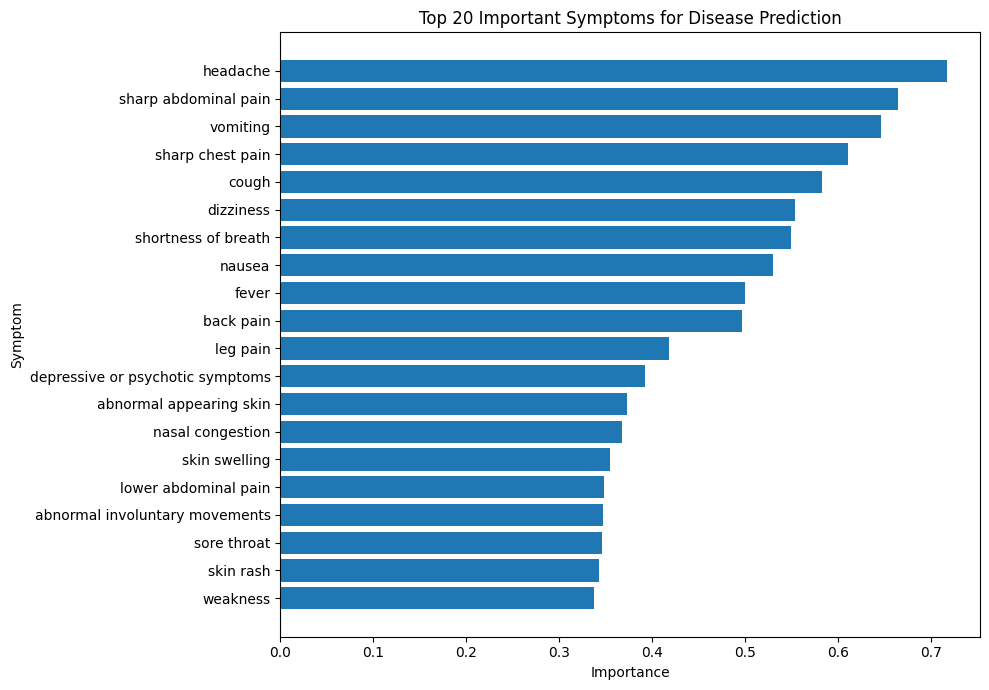

In [31]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Symptom"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Symptom")
plt.title("Top 20 Important Symptoms for Disease Prediction")

plt.tight_layout()
plt.show()